# BUTom21: hand-annotated tomato dataset — dataloader & COCO→YOLO conversion (data preparation)

Reproduction of the **data-preparation workflow** of:

> Halstead, M.; Guclu, E.; Farag, M.; Pallotta, E.; Hund, C.; Roscher, R.; Bennewitz, M.; Gall, J.; Stachniss, C.; McCool, C. — *Still image and spatial-temporal tomato data enabling detection, segmentation, tracking, and video-instance segmentation using strong and weak labels*, arXiv:2607.14934v1 (2026).

**Paper:** https://arxiv.org/abs/2607.14934v1 · **Author code:** https://github.com/Agricultural-Robotics-Bonn/BUTom21-ST21 (pinned commit `dee434707edaba2ce121101ec7f7085c3f5229a0`) · **Data:** [bonndata doi:10.60507/FK2/DHTEH1](https://doi.org/10.60507/FK2/DHTEH1) (CC BY 4.0)

**Scope (executed here):** load the hand-annotated **BUTom21** still-image dataset (293 images: 123 train / 72 valid / 98 eval) with the authors' released PyTorch dataloader, preview a hand annotation, and run the authors' `convert_to_yolo.py` to produce YOLO labels (multiclass, single-class, and depth-filtered variants), with verification against the source COCO annotations.

**Not in scope:** model training, Mask2Former/Yolo26 benchmarks, PAg-NeRF pseudo-labeling, tracking (BUTom-ST21). The authors released no training scripts, trained weights, or tracking/evaluation code (paper §7 Code Availability: "No tracking or evaluation code has been supplied."), so those parts cannot be reproduced from released materials. This notebook reproduces the released data tooling only.

**実行内容（日本語）:** このノートブックは、公開された著者コード（ピン留めコミット）を使って、手でアノテーションされた BUTom21 画像データセットを PyTorch データローダで読み込み、COCO アノテーションを YOLO 形式へ変換する（マルチクラス／シングルクラス／深度フィルタ）データ準備工程を再現します。学習・ベンチマーク・追跡の再現は、資料が公開されていないため対象外です。データセットは CC BY 4.0 で提供されています。

**License notes:** dataset CC BY 4.0. The author repository has **no LICENSE file** (verified at the pinned commit) — code remains © the authors; cite the paper when using it.

## Runtime selection & how to run

This reproduction is **CPU-only** by design: it performs data loading and annotation conversion — no model inference or training — so a GPU adds nothing. Select **Runtime → Change runtime type → CPU** (any default CPU runtime), then **Runtime → Run all**.

Expected durations (estimates, measured on a standard Colab CPU runtime on 2026-10-08): pip install ≈ 2–4 min, 500 MB dataset download ≈ 2–10 min, extraction ≈ 1–3 min, conversions ≈ 3–8 min. Total ≈ **10–25 min**, dominated by the ~500 MB `BUTom21.tar.gz` download. The dataset is distributed as a single tar.gz archive, so the full archive must be downloaded even though this demo reads only a few images; every other file stays on the Colab VM under `/content`.

**実行方法（日本語）:** 「ランタイム → ランタイムのタイプを変更 → CPU」を選び、「ランタイム → すべてのセルを実行」してください。GPU は不要です。全体の目安は 10〜25 分で、大半は約 500 MB のデータセットダウンロードです。

## 1. Environment check

Verify the interpreter and framework versions. The authors' dataloader imports `torch` (incidental, no device work) and their converter uses `ultralytics` label-IO utilities. **JP:** 実行環境のバージョンを確認するセルです。GPU は使用しません。

In [ ]:
import sys, platform
print('Python:', sys.version)
try:
    import torch
    print('torch:', torch.__version__, '| CUDA available:', torch.cuda.is_available())
    if torch.cuda.is_available():
        print('NOTE: a GPU is attached but not needed for this data-preparation demo.')
except Exception as e:
    print('torch unavailable:', repr(e), '(continuing; torch is only imported by the author dataloader)')

Python: 3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]


torch: 2.11.0+cpu | CUDA available: False


## 2. Get the pinned author code (inside Colab)

Clone the authors' repository at the exact verified commit with a pinned, partial clone (`--filter=blob:none --depth 1` on that commit, detached HEAD) and **assert** the checked-out commit matches `dee434707edaba2ce121101ec7f7085c3f5229a0`. All repository bytes stay under `/content` on the Colab VM.

**JP:** 著者リポジトリを、検証済みコミット `dee4347` に固定した部分クローンで取得します（Colab VM 内のみ）。コミット一致をassertで確認します。

In [ ]:
import subprocess, os
REPO_DIR = '/content/BUTom21-ST21'
COMMIT = 'dee434707edaba2ce121101ec7f7085c3f5229a0'
REPO_URL = 'https://github.com/Agricultural-Robotics-Bonn/BUTom21-ST21.git'
if not os.path.isdir(REPO_DIR):
    subprocess.run(['git', 'clone', '--no-checkout', '--filter=blob:none', REPO_URL, REPO_DIR], check=True)
subprocess.run(['git', '-C', REPO_DIR, 'fetch', '--depth', '1', 'origin', COMMIT], check=True)
subprocess.run(['git', '-C', REPO_DIR, 'checkout', '--detach', 'FETCH_HEAD'], check=True)
head = subprocess.run(['git', '-C', REPO_DIR, 'rev-parse', 'HEAD'], capture_output=True, text=True, check=True).stdout.strip()
print('checked-out commit:', head)
assert head == COMMIT, f'commit pin mismatch: {head}'
print('author code ready at', REPO_DIR)

checked-out commit: dee434707edaba2ce121101ec7f7085c3f5229a0
author code ready at /content/BUTom21-ST21


## 3. Install the author dependencies

Install the repository's own `requirements.txt` (unpinned by the authors: numpy, scikit-image, tqdm, pyyaml, opencv-python, ultralytics, pycocotools). Colab's preinstalled torch is left untouched (verified: `pip` does not upgrade it). We then print resolved versions so the environment is reproducible.

**JP:** 著者の requirements.txt をインストールします（torch は Colab 装備のものをそのまま使用）。解決されたパッケージバージョンを表示します。

In [ ]:
import importlib.metadata
!pip install -q --timeout 120 -r {REPO_DIR}/requirements.txt
import torch
print('torch:', torch.__version__)
for pkg in ['numpy', 'scikit-image', 'ultralytics', 'pycocotools', 'opencv-python', 'tqdm', 'pyyaml']:
    try:
        print(pkg, importlib.metadata.version(pkg))
    except importlib.metadata.PackageNotFoundError:
        print(pkg, 'NOT FOUND')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 2.7 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 7.3 MB/s eta 0:00:00


torch: 2.11.0+cpu
numpy 2.1.3
scikit-image 0.25.2
ultralytics 8.4.174
pycocotools 2.0.11
opencv-python 5.0.0.93
tqdm 4.67.3
pyyaml 6.0.3


## 4. Download the BUTom21 dataset with checksum verification

Provenance: **bonndata (Dataverse), doi:10.60507/FK2/DHTEH1, version 1.0, license CC BY 4.0**, file `BUTom21.tar.gz`, **500,703,195 bytes, MD5 `09ba15fe38e8b1997f31bce6e9224753`** (from the public record metadata API). The download uses the documented public access route `GET /api/access/datafile/{id}` (file id 54901) — no login or token. The MD5 and byte size are verified **before** extraction; a mismatch raises and stops.

**JP:** データセット（約500 MB, 単一 tar.gz）を bonndata の公開API経由で Colab 内にダウンロードし、サイズと MD5 を検証します。一致しない場合は中断します。

In [ ]:
import urllib.request, hashlib, time
DATA_URL = 'https://bonndata.uni-bonn.de/api/access/datafile/54901'  # BUTom21.tar.gz, file id from public record metadata
EXPECTED_SIZE = 500703195
EXPECTED_MD5 = '09ba15fe38e8b1997f31bce6e9224753'
ARCHIVE = '/content/BUTom21.tar.gz'
t0 = time.time()
if not os.path.exists(ARCHIVE) or os.path.getsize(ARCHIVE) != EXPECTED_SIZE:
    req = urllib.request.Request(DATA_URL, headers={'User-Agent': 'colab-butom21-repro/1.0'})
    with urllib.request.urlopen(req, timeout=300) as resp, open(ARCHIVE, 'wb') as fh:
        assert resp.status == 200, f'HTTP {resp.status}'
        total = 0
        while True:
            chunk = resp.read(1 << 20)
            if not chunk:
                break
            fh.write(chunk); total += len(chunk)
            if total % (50 << 20) < (1 << 20):
                print(f'  downloaded {total/1e6:.0f} MB ...', flush=True)
print(f'download finished: {os.path.getsize(ARCHIVE)} bytes in {time.time()-t0:.0f} s')
assert os.path.getsize(ARCHIVE) == EXPECTED_SIZE, 'size mismatch'
h = hashlib.md5()
with open(ARCHIVE, 'rb') as fh:
    for chunk in iter(lambda: fh.read(1 << 20), b''):
        h.update(chunk)
print('MD5:', h.hexdigest())
assert h.hexdigest() == EXPECTED_MD5, 'MD5 mismatch — do not use this payload'

  downloaded 52 MB ...


  downloaded 105 MB ...


  downloaded 157 MB ...


  downloaded 210 MB ...


  downloaded 262 MB ...


...

  downloaded 367 MB ...


  downloaded 419 MB ...


  downloaded 472 MB ...


download finished: 500703195 bytes in 16 s


MD5: 09ba15fe38e8b1997f31bce6e9224753


## 5. Extract the archive and inspect its structure

Extract safely (`tarfile` with `filter='data'`) and print the top-level layout, the authors' structure document and ReadMe (small text members of the dataset), and locate the dataset root containing `CKA_tomato_2021.yaml` (subset image lists) and `CKA_tomato_2021.json` (COCO annotations) — the two files the authors' converter expects at the dataset root.

**JP:** アーカイブを安全に展開し、構造とデータセット付属の説明書を表示します。変換スクリプトが期待する `CKA_tomato_2021.yaml/json` の位置を確認します。

In [ ]:
import tarfile, glob
with tarfile.open(ARCHIVE, 'r:gz') as tar:
    tar.extractall('/content/butom21', filter='data')
top = sorted(os.listdir('/content/butom21'))
print('top-level entries:', top)
for doc in ['BUTom21_structure.md', 'Halstead_BUTom21_ReadMe.txt']:
    hits = glob.glob(f'/content/butom21/**/{doc}', recursive=True)
    if hits:
        text = open(hits[0]).read()
        print(f'--- {doc} (first 30 lines) ---')
        print('\n'.join(text.splitlines()[:30]))
yaml_hits = glob.glob('/content/butom21/**/CKA_tomato_2021.yaml', recursive=True)
json_hits = glob.glob('/content/butom21/**/CKA_tomato_2021.json', recursive=True)
assert yaml_hits and json_hits, 'dataset yaml/json not found'
ROOT_DATASET = os.path.dirname(yaml_hits[0])
print('dataset root:', ROOT_DATASET)
print('subdirectories:', sorted(os.listdir(ROOT_DATASET)))

top-level entries: ['BUTom21']
dataset root: /content/butom21/BUTom21
subdirectories: ['CKA_Tomato_2021_images', 'CKA_tomato_2021.json', 'CKA_tomato_2021.yaml', 'image_camera_row_identity.yaml']


## 6. Load BUTom21 with the authors' PyTorch dataloader

Instantiate the authors' `BUPTom21_dataloader` (from `engine/dataloaders/BUTom21.py`, **unchanged**) for each subset and confirm the documented split sizes (123 train / 72 valid / 98 eval, per the bonndata record and paper Table 1). `getImgGT` returns the RGB image (float, /255), per-instance COCO masks, ripeness class labels, and COCO bboxes.

One path convention, observed from the extracted archive and kept faithful to the author code: the COCO `path` fields end with `.../CKA_Tomato_2021_images/<date>/<row>/rgb/<file>.png`. The example dataloader resolves images from the **last 4** path components, so its `root` is the `CKA_Tomato_2021_images` directory, while the authors' YOLO converter class (section 8) uses the **last 5** and takes the dataset root. We pass each class its matching root rather than modifying the author source.

**JP:** 著者のデータローダ（無変更）で各サブセットを読み込み、文書化された分割数 123/72/98 と一致することを確認します。画像は `CKA_Tomato_2021_images/` 配下にあるため、データローダにはそのディレクトリを root として渡します（変換クラスはデータセット root を使用）。

In [ ]:
import sys
sys.path.insert(0, REPO_DIR)
from engine.dataloaders.BUTom21 import BUPTom21_dataloader
yaml_file = os.path.join(ROOT_DATASET, 'CKA_tomato_2021.yaml')
json_file = os.path.join(ROOT_DATASET, 'CKA_tomato_2021.json')
# Path convention (observed from the extracted archive): COCO `path` fields end
# with .../CKA_Tomato_2021_images/<date>/<row>/rgb/<file>. The authors' example
# dataloader resolves images from the LAST 4 path components, so its `root` is
# the CKA_Tomato_2021_images directory; the authors' YOLO converter class (used
# below) uses the LAST 5 and takes the dataset root. Author code is unchanged.
IMG_ROOT = os.path.join(ROOT_DATASET, 'CKA_Tomato_2021_images')
DATASETS = {s: BUPTom21_dataloader(IMG_ROOT, yaml_file, json_file, subset=s)
            for s in ['train', 'valid', 'eval']}
for s, ds in DATASETS.items():
    print(f'{s}: {len(ds)} images')
assert [len(DATASETS[s]) for s in ['train', 'valid', 'eval']] == [123, 72, 98], 'split sizes differ from the documented 123/72/98'
cats = {c['id']: c['name'] for c in DATASETS['train'].coco.dataset['categories']}
print('categories (id -> ripeness subclass):', cats)
idx = 0
img, masks, labels, bboxes, filename = DATASETS['train'][idx]
print('example', idx, ':', filename)
print('  image shape (H,W,C):', img.shape, '| instance masks:', masks.shape, '| labels:', labels.tolist())

loading annotations into memory...


Done (t=1.46s)
creating index...
index created!
loading annotations into memory...


Done (t=1.41s)
creating index...
index created!
loading annotations into memory...


Done (t=1.43s)
creating index...
index created!
train: 123 images
valid: 72 images
eval: 98 images
categories (id -> ripeness subclass): {0: 'red', 1: 'mixed_red', 2: 'green', 3: 'orange', 4: 'mixed_orange'}


example 0 : 1631265697420627117.png
  image shape (H,W,C): (1280, 720, 3) | instance masks: (1280, 720, 11) | labels: [2, 2, 2, 0, 0, 0, 4, 2, 2, 2, 0]


## 7. Preview a hand annotation (reference annotation, not a prediction)

Display the example still image next to the **authors' hand-made reference annotation** (COCO instance masks per ripeness subclass + bounding boxes) exactly as returned by the authors' dataloader. These are ground-truth labels shipped with the dataset — not model output. This figure is saved as a PNG for the run record.

**JP:** 手で作成された正解アノテーション（COCO マスク＋バウンディングボックス）を元画像と並べて表示します。これはモデル予測ではなく、データセット付属の参照ラベルです。

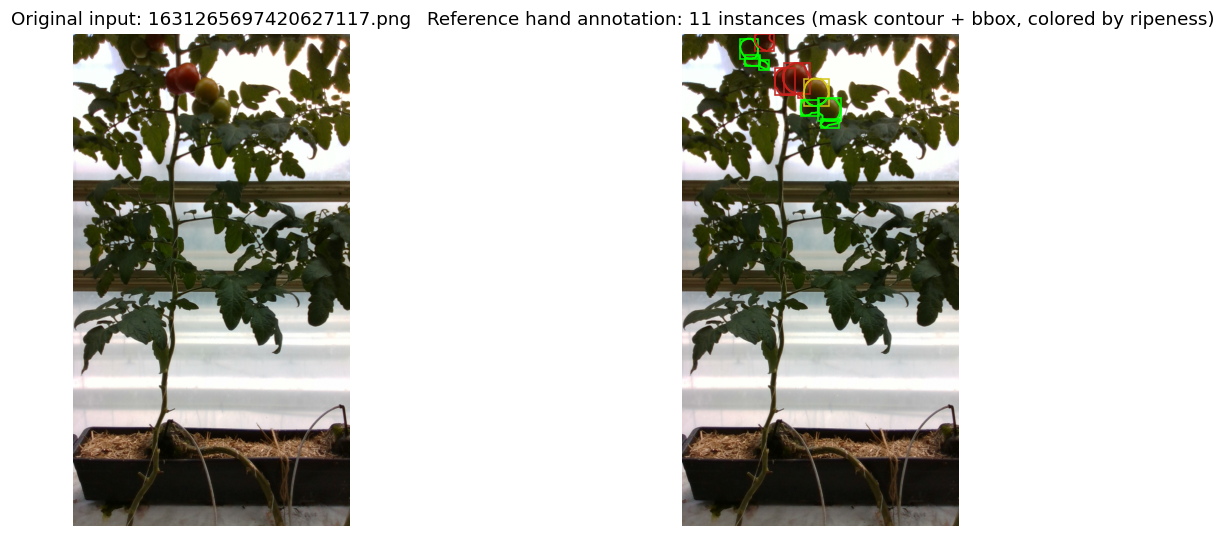

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import Image as IPyImage
CLASS_COLORS = {'red': '#c7211c', 'mixed_red': '#fff700', 'green': '#00ff00',
                'orange': '#ff6600', 'mixed_orange': '#d1c415'}  # authors' colors from engine/conversions/converters.py
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img); axes[0].set_title(f'Original input: {filename}'); axes[0].axis('off')
axes[1].imshow(img)
for i in range(masks.shape[-1]):
    cat_id = int(labels[i])
    name = cats.get(cat_id, str(cat_id))
    color = CLASS_COLORS.get(name, '#00ffff')
    m = masks[..., i]
    axes[1].contour(m, levels=[0.5], colors=[color], linewidths=1.2)
    x, y, w, hgt = bboxes[i]
    axes[1].add_patch(Rectangle((x, y), w, hgt, fill=False, edgecolor=color, linewidth=1.0))
axes[1].set_title(f'Reference hand annotation: {masks.shape[-1]} instances (mask contour + bbox, colored by ripeness)')
axes[1].axis('off')
plt.tight_layout(); plt.savefig('/content/butom21_reference_annotation_preview.png', dpi=110, bbox_inches='tight'); plt.close(fig)
display(IPyImage(filename='/content/butom21_reference_annotation_preview.png'))

## 8. Run the authors' COCO→YOLO conversion (multiclass, unfiltered)

This runs the authors' own script `convert_to_yolo.py` verbatim with the README's multi-class command (`--class_mapping_dict 0:0 1:1 2:2 3:3 4:4`): it copies the subset images and writes `json_files_multiclass/<subset>.json`, then converts those COCO files to YOLO segmentation labels (`labels_multiclass/<subset>/*.txt`) via the authors' `convert_coco` copy, and writes a `BUTom21_multiclass.yaml` for Ultralytics training.

**JP:** 著者スクリプト `convert_to_yolo.py` を README のマルチクラス指定そのままで実行します（画像コピー＋COCO→YOLO 変換＋dataset yaml 生成）。

In [ ]:
import time
t_conv = time.time()
!cd {REPO_DIR} && python convert_to_yolo.py --root_dataset_directory {ROOT_DATASET} --class_mapping_dict 0:0 1:1 2:2 3:3 4:4
print(f'conversion wall time: {time.time()-t_conv:.0f} s')

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


You are saving to the directory: /content/butom21/BUTom21/Yolo_Dataset
loading annotations into memory...


Done (t=2.53s)
creating index...
index created!
Filtering annotations for subset 'train'...
  0% 0/123 [00:00<?, ?it/s]

  1% 1/123 [00:00<01:47,  1.14it/s]

  2% 2/123 [00:01<01:18,  1.54it/s]

...

Annotations /content/butom21/BUTom21/Yolo_Dataset/json_files_multiclass/valid.json: 69% ━━━━━━━━──── 50/72 24.2it/s 1.9s<0.9s

Annotations /content/butom21/BUTom21/Yolo_Dataset/json_files_multiclass/valid.json: 79% ━━━━━━━━━─── 57/72 20.7it/s 2.3s<0.7s

Annotations /content/butom21/BUTom21/Yolo_Dataset/json_files_multiclass/valid.json: 88% ━━━━━━━━━━╸─ 64/72 26.1it/s 2.5s<0.3s

Annotations /content/butom21/BUTom21/Yolo_Dataset/json_files_multiclass/valid.json: 100% ━━━━━━━━━━━━ 72/72 24.5it/s 2.9s
COCO data converted successfully.
Results saved to /content/butom21/BUTom21/Yolo_Dataset/labels_multiclass


conversion wall time: 189 s


## 9. Verify the produced YOLO dataset against the source COCO annotations

Independent verification of the conversion result: per-subset image counts, YOLO label file counts, a parsed sample label (class id + normalized segmentation coordinates), the generated dataset yaml, and — the strongest check — that the unfiltered multiclass conversion preserved **every** annotation of the source COCO JSON (no depth filtering ⇒ no annotation may be dropped). Note the authors' `convert_coco` copy nests label files under `labels_multiclass/labels/<subset>/` (their README explains renaming to `labels` for Ultralytics training).

**JP:** 変換結果を検証します：各分割の画像・ラベル数、ラベルファイルのサンプル、生成された dataset yaml、そして「深度フィルタ無しでは全アノテーションが保持される」ことを元の COCO JSON と突き合わせて確認します。ラベルは `labels_multiclass/labels/<subset>/` に入ります（著者コードの構造）。

In [ ]:
import json, yaml as _yaml
YOLO_DIR = os.path.join(ROOT_DATASET, 'Yolo_Dataset')
print('Yolo_Dataset entries:', sorted(os.listdir(YOLO_DIR)))
# The authors' convert_coco copy nests the label txt files under <labels_dir>/labels/<subset>/
# (their README notes renaming to `labels` for Ultralytics training).
verification = {}
for subset in ['train', 'valid', 'eval']:
    n_img = len(os.listdir(os.path.join(YOLO_DIR, 'images', subset)))
    n_lbl = len(os.listdir(os.path.join(YOLO_DIR, 'labels_multiclass', 'labels', subset)))
    verification[subset] = {'images': n_img, 'label_files': n_lbl}
    print(f'{subset}: images={n_img}, label files={n_lbl}')
src = json.load(open(json_file))
image_sets = _yaml.safe_load(open(yaml_file))['image_sets']
src_train_ann_count = sum(1 for a in src['annotations'] if a['image_id'] in set(image_sets['train']))
conv_anns = json.load(open(os.path.join(YOLO_DIR, 'json_files_multiclass', 'train.json')))['annotations']
print(f'source COCO train annotations: {src_train_ann_count}; converted (multiclass, unfiltered): {len(conv_anns)}')
assert len(conv_anns) == src_train_ann_count, 'annotation count changed without depth filtering'
sample_lbl = sorted(os.listdir(os.path.join(YOLO_DIR, 'labels_multiclass', 'labels', 'train')))[0]
lines = open(os.path.join(YOLO_DIR, 'labels_multiclass', 'labels', 'train', sample_lbl)).read().splitlines()
print(f'sample label {sample_lbl}: {len(lines)} instances; first line (class + normalized polygon, truncated):')
print(' ', lines[0][:120] + ('...' if len(lines[0]) > 120 else ''))
tok = lines[0].split()
assert tok[0] in {'0', '1', '2', '3', '4'} and all(0.0 <= float(v) <= 1.0 for v in tok[1:]), 'malformed YOLO label'
print(open(os.path.join(YOLO_DIR, 'BUTom21_multiclass.yaml')).read())

Yolo_Dataset entries: ['BUTom21_multiclass.yaml', 'images', 'json_files_multiclass', 'labels_multiclass']
train: images=123, label files=123
valid: images=72, label files=72
eval: images=98, label files=98


source COCO train annotations: 8050; converted (multiclass, unfiltered): 8050
sample label 1629277558049203873.txt: 25 instances; first line (class + normalized polygon, truncated):
  2 0.596528 0.122969 0.608333 0.122969 0.608889 0.122812 0.610833 0.122812 0.611944 0.122578 0.6125 0.122188 0.6125 0.122...
path: /content/butom21/BUTom21/Yolo_Dataset
train: images/train
val: images/valid
test: images/eval
names:
  0: red
  1: mixed_red
  2: green
  3: orange
  4: mixed_orange



## 10. Single-class and depth-filtered variants

Two more README-documented variants, run with `--annotations_only` (images are already copied): **single-class** maps all five ripeness subclasses to one `tomato` class, and **multiclass depth-filtered** keeps an instance only if ≥45% of its mask pixels lie within 1.4 m of the camera (the authors' defaults `--depth_distance 1400 --depth_count_probability 0.45`; paper §2 describes the depth filter as "at least 50% within 1.4 m" — the released code default 0.45 is what the script actually applies). This exercises the authors' `check_bg_object` depth rule on the real depth images.

**JP:** シングルクラス版と、深度フィルタ版（既定値：1.4 m 以内にマスク画素の45%以上）を `--annotations_only` で実行します。深度フィルタは著者コード `check_bg_object` がそのまま使われます。

In [ ]:
t_sc = time.time()
!cd {REPO_DIR} && python convert_to_yolo.py --root_dataset_directory {ROOT_DATASET} --class_mapping_dict 0:0 1:0 2:0 3:0 4:0 --output_single_class --annotations_only
print(f'single-class wall time: {time.time()-t_sc:.0f} s')
t_df = time.time()
!cd {REPO_DIR} && python convert_to_yolo.py --root_dataset_directory {ROOT_DATASET} --class_mapping_dict 0:0 1:1 2:2 3:3 4:4 --output_depth_filtered --annotations_only
print(f'depth-filtered wall time: {time.time()-t_df:.0f} s')
for d in ['json_files_singleclass', 'json_files_multiclass_depthfitered', 'labels_singleclass', 'labels_multiclass_depthfiltered']:
    p = os.path.join(YOLO_DIR, d)
    print(d, '->', sorted(os.listdir(p)) if os.path.isdir(p) else 'MISSING')
sc = json.load(open(os.path.join(YOLO_DIR, 'json_files_singleclass', 'train.json')))['annotations']
mc = json.load(open(os.path.join(YOLO_DIR, 'json_files_multiclass_depthfitered', 'train.json')))['annotations']
mc_all = json.load(open(os.path.join(YOLO_DIR, 'json_files_multiclass', 'train.json')))['annotations']
print(f'single-class train annotations: {len(sc)} (all mapped to class {set(a["category_id"] for a in sc)})')
print(f'depth-filtered multiclass train annotations: {len(mc)} of {len(mc_all)} kept by the 1.4 m / 45% rule')

You are saving to the directory: /content/butom21/BUTom21/Yolo_Dataset
loading annotations into memory...


Done (t=1.43s)
creating index...
index created!
Filtering annotations for subset 'train'...
  0% 0/123 [00:00<?, ?it/s]

  2% 2/123 [00:00<00:10, 11.83it/s]

  3% 4/123 [00:00<00:12,  9.52it/s]

  7% 8/123 [00:00<00:13,  8.79it/s]

...

Annotations /content/butom21/BUTom21/Yolo_Dataset/json_files_multiclass_depthfitered/valid.json: 70% ━━━━━━━━──── 51/72 28.5it/s 1.5s<0.7s

Annotations /content/butom21/BUTom21/Yolo_Dataset/json_files_multiclass_depthfitered/valid.json: 80% ━━━━━━━━━╸── 58/72 28.0it/s 1.8s<0.5s

Annotations /content/butom21/BUTom21/Yolo_Dataset/json_files_multiclass_depthfitered/valid.json: 100% ━━━━━━━━━━━━ 72/72 34.1it/s 2.1s
COCO data converted successfully.
Results saved to /content/butom21/BUTom21/Yolo_Dataset/labels_multiclass_depthfiltered


depth-filtered wall time: 128 s
json_files_singleclass -> ['eval.json', 'train.json', 'valid.json']
json_files_multiclass_depthfitered -> ['eval.json', 'train.json', 'valid.json']
labels_singleclass -> ['images', 'labels']
labels_multiclass_depthfiltered -> ['images', 'labels']


single-class train annotations: 8050 (all mapped to class {1})
depth-filtered multiclass train annotations: 4479 of 8050 kept by the 1.4 m / 45% rule


## 11. Ripeness class distribution of the hand annotations

A summary graph **created for this notebook** (not an author figure): instance counts per ripeness subclass in each subset, counted directly from the source COCO annotations via the authors' dataloader split lists. It shows the class balance the paper documents for BUTom21.

**JP:** 元の COCO アノテーションから、サブセット別・熟度クラス別のインスタンス数を集計した棒グラフです（本ノートブックで追加作成した可視化であり、論文の図ではありません）。

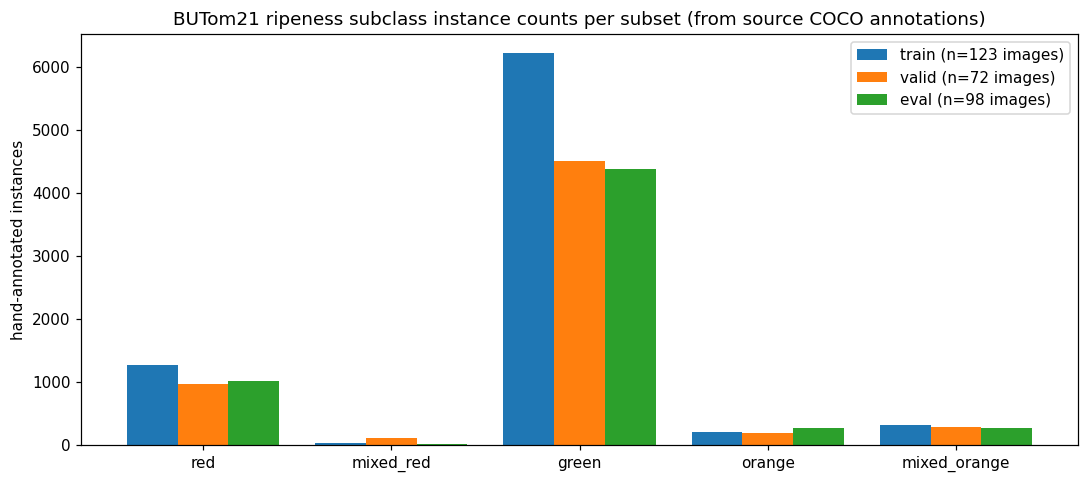

    subclass  train  valid  eval
         red   1271    963  1013
   mixed_red     40    107    20
       green   6210   4508  4373
      orange    211    186   266
mixed_orange    318    292   278


In [ ]:
from collections import Counter
import numpy as np
counts = {}
for s in ['train', 'valid', 'eval']:
    ds = DATASETS[s]
    c = Counter()
    for img_id in ds.image_sets[s]:
        for ann in ds.coco.loadAnns(ds.coco.getAnnIds(imgIds=img_id)):
            c[cats[ann['category_id']]] += 1
    counts[s] = c
order = ['red', 'mixed_red', 'green', 'orange', 'mixed_orange']
x = np.arange(len(order)); width = 0.27
fig, ax = plt.subplots(figsize=(10, 4.5))
for j, s in enumerate(['train', 'valid', 'eval']):
    ax.bar(x + (j - 1) * width, [counts[s].get(k, 0) for k in order], width, label=f'{s} (n={len(DATASETS[s])} images)')
ax.set_xticks(x); ax.set_xticklabels(order)
ax.set_ylabel('hand-annotated instances')
ax.set_title('BUTom21 ripeness subclass instance counts per subset (from source COCO annotations)')
ax.legend(); plt.tight_layout()
plt.savefig('/content/butom21_class_distribution.png', dpi=110, bbox_inches='tight'); plt.close(fig)
display(IPyImage(filename='/content/butom21_class_distribution.png'))
import pandas as pd
df = pd.DataFrame([{**{'subclass': k}, **{s: counts[s].get(k, 0) for s in ['train', 'valid', 'eval']}} for k in order])
print(df.to_string(index=False))
df.to_csv('/content/butom21_class_distribution.csv', index=False)

## 12. Summary, limitations and validation record

This notebook reproduced, on the executed runtime, the released **data-preparation** portion of arXiv:2607.14934v1: the BUTom21 dataloader, a reference-annotation preview, and the authors' COCO→YOLO conversions (multiclass, single-class, depth-filtered) with annotation-count verification against the source COCO JSON.

**Limitations / 出典と限界（日本語）:**
- 学習済みモデル重み・学習スクリプト・追跡/評価コードは公開されていないため（論文 §7）、ベンチマーク表の再現は不可能です。
- 単一アーカイブ配布のため約 500 MB の完全ダウンロードが必要です（デモが読むのはごく一部の画像です）。
- 深度フィルタの閾値は著者コード既定値（1.4 m, 45%）を使用しました。論文本文は「少なくとも50%」と記述します。
- 実行したのはデータ準備の最小例であり、論文のデータセット全体の品質評価を検証するものではありません。

Measured timings and counts are printed by the cell below from the actual run.

**References:** paper (arXiv:2607.14934v1) · code repo `Agricultural-Robotics-Bonn/BUTom21-ST21` @ `dee434707edaba2ce121101ec7f7085c3f5229a0` · data [doi:10.60507/FK2/DHTEH1](https://doi.org/10.60507/FK2/DHTEH1) (CC BY 4.0) · PhenoPaper investigation `p-872c46dfb335fe02801fd6ff531b1a55-20261008T012056Z-580382` used as unverified research guidance only.

In [ ]:
import json as _json
summary = {
    'split_sizes': {s: len(DATASETS[s]) for s in ['train', 'valid', 'eval']},
    'yolo_verification': verification,
    'archive': {'bytes': EXPECTED_SIZE, 'md5': EXPECTED_MD5, 'verified': True},
}
print(_json.dumps(summary, indent=2))
print('Yolo_Dataset location:', YOLO_DIR)
print('Preview PNGs saved: /content/butom21_reference_annotation_preview.png, /content/butom21_class_distribution.png')

{
  "split_sizes": {
    "train": 123,
    "valid": 72,
    "eval": 98
  },
  "yolo_verification": {
    "train": {
      "images": 123,
      "label_files": 123
    },
    "valid": {
      "images": 72,
      "label_files": 72
    },
    "eval": {
      "images": 98,
      "label_files": 98
    }
  },
  "archive": {
    "bytes": 500703195,
    "md5": "09ba15fe38e8b1997f31bce6e9224753",
    "verified": true
  }
}
Yolo_Dataset location: /content/butom21/BUTom21/Yolo_Dataset
Preview PNGs saved: /content/butom21_reference_annotation_preview.png, /content/butom21_class_distribution.png
